# PREDIKSI TINGKAT KEPUASAN PENGGUNA APLIKASI PEMBELAJARAN DARING

Studi kasus menggunakan metodologi CRISP-DM untuk membangun model klasifikasi biner

**Tujuan:**
- Eksplorasi dan pemahaman dataset
- Preprocessing dan transformasi data
- Membangun 4 model klasifikasi
- Evaluasi performa dan ensemble voting

**Algoritma:**
- Logistic Regression (Baseline)
- Naive Bayes (Probabilistik)
- Decision Tree (Non-linear)
- KNN (Distance-based)

## SETUP & IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Setup berhasil!")

✅ Setup berhasil!


# 1. DATA UNDERSTANDING

## 1.1 Load & Preview Data

In [2]:
df = pd.read_csv('dataset_kepuasan_pengguna_elearning.csv')

print("=" * 70)
print("📋 DATASET OVERVIEW")
print("=" * 70)
print(f"\nDataset: Kepuasan Pengguna Aplikasi Pembelajaran Daring")
print(f"Shape: {df.shape}")
print(f"Samples: {df.shape[0]}")
print(f"Features: {df.shape[1]}")

📋 DATASET OVERVIEW

Dataset: Kepuasan Pengguna Aplikasi Pembelajaran Daring
Shape: (500, 10)
Samples: 500
Features: 10


## 1.2 Struktur Data

In [3]:
print("=" * 70)
print("📐 STRUKTUR DATA")
print("=" * 70)

print("\nKolom Dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\n\nPREVIEW DATA (5 BARIS):")
df.head()

📐 STRUKTUR DATA

Kolom Dataset:
 1. id_responden
 2. usia
 3. jenis_kelamin
 4. durasi_penggunaan
 5. frekuensi_login
 6. kualitas_materi
 7. kemudahan_penggunaan
 8. stabilitas_aplikasi
 9. interaksi_pengajar
10. kepuasan_pengguna


PREVIEW DATA (5 BARIS):


,id_responden,usia,jenis_kelamin,durasi_penggunaan,frekuensi_login,kualitas_materi,kemudahan_penggunaan,stabilitas_aplikasi,interaksi_pengajar,kepuasan_pengguna
0,R0001,27,L,3.2,3,4.0,4,5.0,3,1
1,R0002,33,L,2.4,6,5.0,4,2.0,4,1
2,R0003,22,L,3.1,1,2.0,4,5.0,4,1
3,R0004,34,P,3.2,3,4.0,5,1.0,1,0
4,R0005,34,L,4.8,3,4.0,4,4.0,2,1


## 1.3 Tipe Data & Info

In [4]:
print("=" * 70)
print("🔍 TIPE DATA")
print("=" * 70)

data_types = pd.DataFrame({
    'Kolom': df.columns,
    'Tipe': df.dtypes,
    'Non-Null': df.count(),
    'Null': df.isnull().sum()
})

print("\n" + data_types.to_string(index=False))

print(f"\n\nRINGKASAN:")
print(f"Object: {sum(df.dtypes == 'object')} kolom")
print(f"Integer: {sum(df.dtypes == 'int64')} kolom")
print(f"Float: {sum(df.dtypes == 'float64')} kolom")

🔍 TIPE DATA

               Kolom    Tipe  Non-Null  Null
        id_responden  object       500     0
                usia   int64       500     0
       jenis_kelamin  object       500     0
   durasi_penggunaan float64       470    30
     frekuensi_login   int64       500     0
     kualitas_materi float64       470    30
kemudahan_penggunaan   int64       500     0
 stabilitas_aplikasi float64       470    30
  interaksi_pengajar   int64       500     0
   kepuasan_pengguna   int64       500     0


RINGKASAN:
Object: 2 kolom
Integer: 5 kolom
Float: 3 kolom


## 1.4 Statistik Deskriptif

In [5]:
print("=" * 70)
print("📊 STATISTIK DESKRIPTIF")
print("=" * 70)

print("\n" + df.describe().to_string())

📊 STATISTIK DESKRIPTIF

             usia  durasi_penggunaan  frekuensi_login  kualitas_materi  kemudahan_penggunaan  stabilitas_aplikasi  interaksi_pengajar  kepuasan_pengguna
count  500.000000         470.000000       500.000000       470.000000             500.00000           470.000000          500.000000         500.000000
mean    26.004000           3.279574         4.014000         3.127660               3.09800             2.976596            2.922000           0.504000
std      5.009008           1.664571         2.014428         1.385533               1.41577             1.443124            1.454699           0.500485
min     18.000000           0.300000         1.000000         1.000000               1.00000             1.000000            1.000000           0.000000
25%     21.000000           1.800000         2.000000         2.000000               2.00000             2.000000            1.750000           0.000000
50%     26.000000           3.300000         4.000000     

## 1.5 Missing Values & Duplikat

In [6]:
print("=" * 70)
print("🔍 DATA QUALITY CHECK")
print("=" * 70)

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Kolom': missing_values.index,
    'Missing': missing_values.values,
    'Persen': missing_percent.values
})

missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_df) > 0:
    print("\nMissing Values:")
    print(missing_df.to_string(index=False))
else:
    print("\n✅ Tidak ada missing values")

duplikat = df.duplicated().sum()
print(f"\nData Duplikat: {duplikat}")

🔍 DATA QUALITY CHECK

Missing Values:
              Kolom  Missing  Persen
  durasi_penggunaan       30     6.0
    kualitas_materi       30     6.0
stabilitas_aplikasi       30     6.0

Data Duplikat: 0


## 1.6 Distribusi Target

In [7]:
print("=" * 70)
print("📊 DISTRIBUSI KELAS TARGET")
print("=" * 70)

target_dist = df['kepuasan_pengguna'].value_counts().sort_index()
target_percent = df['kepuasan_pengguna'].value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({
    'Kelas': ['Tidak Puas (0)', 'Puas (1)'],
    'Jumlah': [target_dist[0], target_dist[1]],
    'Persen': [target_percent[0], target_percent[1]]
})

print("\n" + dist_df.to_string(index=False))

balance_ratio = min(target_dist) / max(target_dist)
print(f"\nBalance Ratio: {balance_ratio:.3f}")
if balance_ratio >= 0.8:
    print("✅ Dataset seimbang")
elif balance_ratio >= 0.5:
    print("⚠️ Dataset agak tidak seimbang")
else:
    print("❌ Dataset tidak seimbang")

📊 DISTRIBUSI KELAS TARGET

         Kelas  Jumlah  Persen
Tidak Puas (0)     248    49.6
      Puas (1)     252    50.4

Balance Ratio: 0.984
✅ Dataset seimbang


## 1.7 Visualisasi Distribusi Target

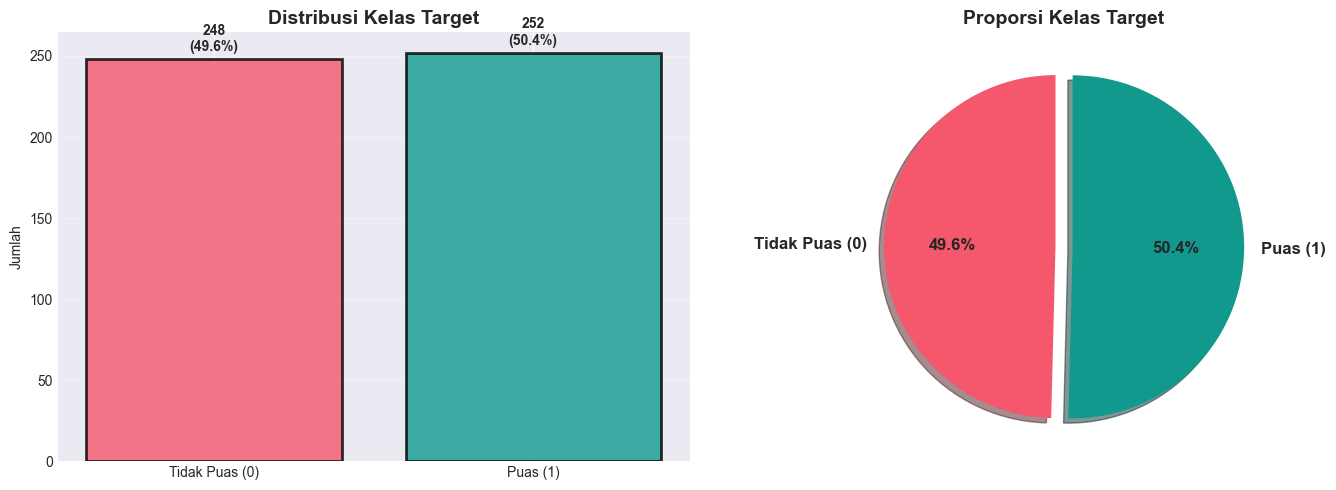

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#f5576c', '#11998e']
bars = axes[0].bar(dist_df['Kelas'], dist_df['Jumlah'], color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
axes[0].grid(True, alpha=0.3, axis='y')

for bar, v, p in zip(bars, dist_df['Jumlah'], target_percent):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 5, f'{v}\n({p:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(dist_df['Jumlah'], labels=dist_df['Kelas'], autopct='%1.1f%%', colors=colors, 
            startangle=90, explode=(0.05, 0.05), shadow=True, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 1.8 Eksplorasi Fitur Numerik

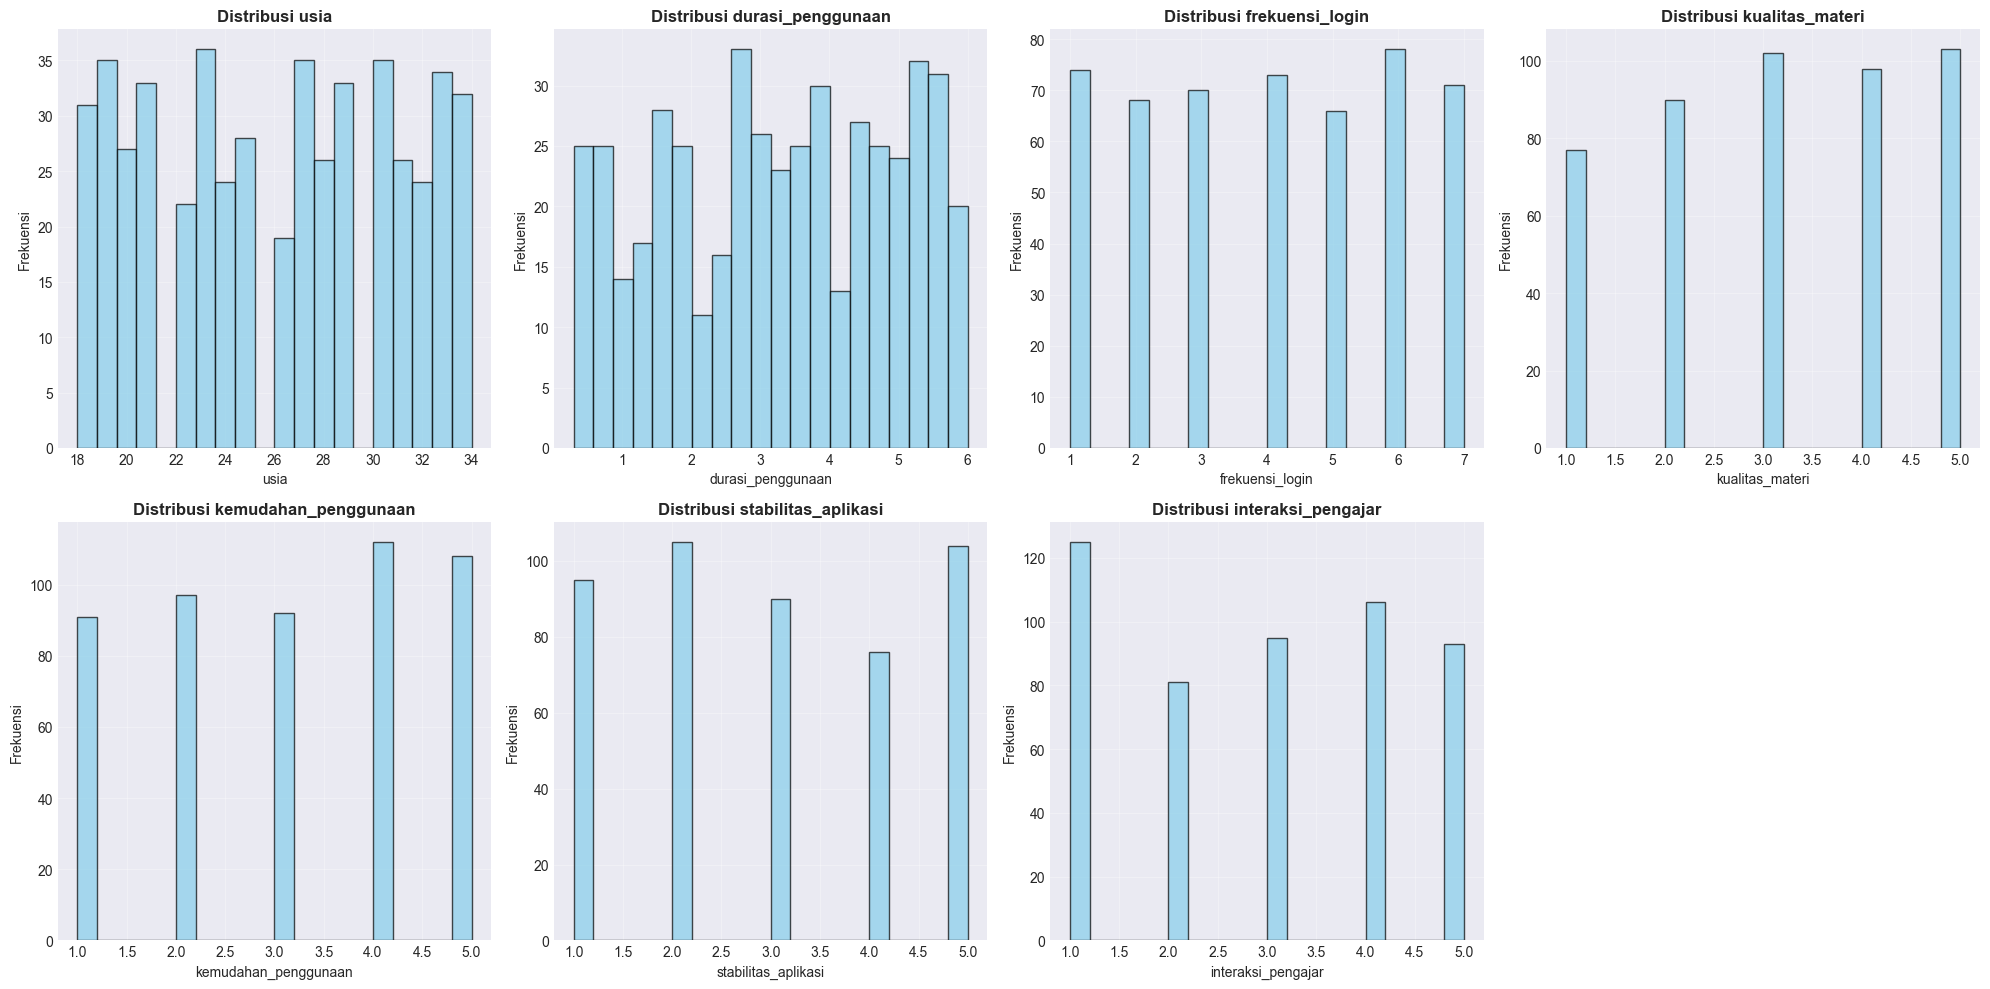

In [9]:
numerical_cols = ['usia', 'durasi_penggunaan', 'frekuensi_login', 'kualitas_materi', 
                  'kemudahan_penggunaan', 'stabilitas_aplikasi', 'interaksi_pengajar']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if col in df.columns:
        axes[idx].hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribusi {col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frekuensi')
        axes[idx].grid(True, alpha=0.3)

axes[7].axis('off')
plt.tight_layout()
plt.show()

## 1.9 Korelasi Antar Fitur

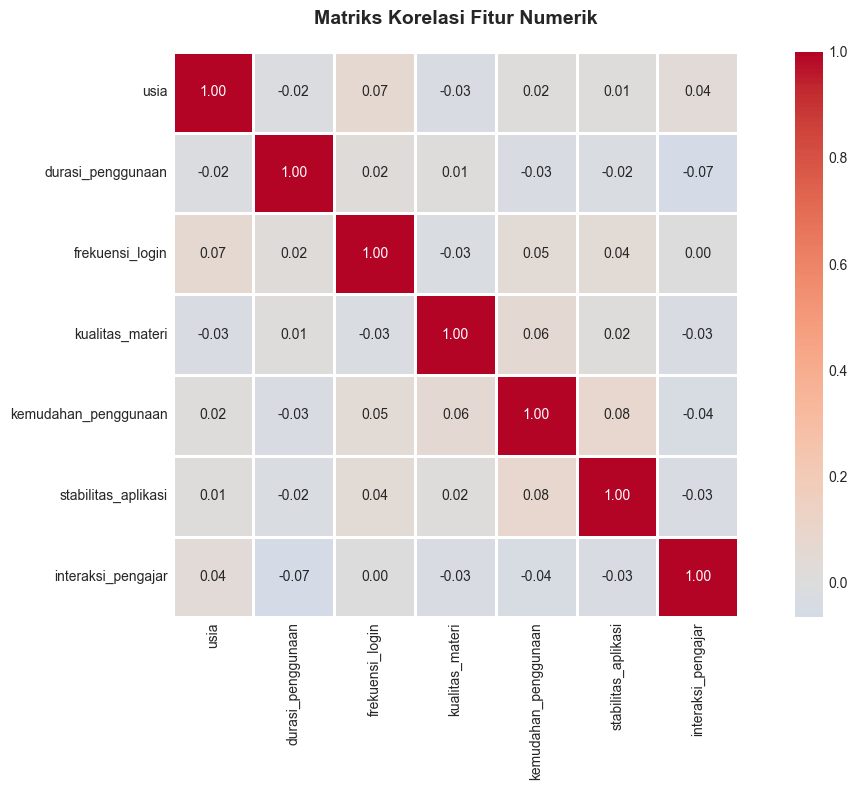

In [10]:
numerical_df = df[numerical_cols].select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Matriks Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 2. DATA PREPARATION

## 2.1 Copy Data untuk Preprocessing

In [11]:
df_clean = df.copy()

print("=" * 70)
print("🧹 DATA PREPROCESSING")
print("=" * 70)
print(f"\nShape sebelum: {df_clean.shape}")

🧹 DATA PREPROCESSING

Shape sebelum: (500, 10)


## 2.2 Hapus Atribut Tidak Relevan

In [12]:
print("\n" + "=" * 70)
print("🗑️ PENGHAPUSAN ATRIBUT TIDAK RELEVAN")
print("=" * 70)

before_cols = df_clean.shape[1]
df_clean = df_clean.drop('id_responden', axis=1)
after_cols = df_clean.shape[1]

print(f"\nAtribut dihapus: id_responden")
print(f"Kolom sebelum: {before_cols}")
print(f"Kolom sesudah: {after_cols}")


🗑️ PENGHAPUSAN ATRIBUT TIDAK RELEVAN

Atribut dihapus: id_responden
Kolom sebelum: 10
Kolom sesudah: 9


## 2.3 Hapus Data Duplikat

In [13]:
print("\n" + "=" * 70)
print("🔍 PENGHAPUSAN DATA DUPLIKAT")
print("=" * 70)

before_dup = len(df_clean)
duplikat_count = df_clean.duplicated().sum()

print(f"\nBaris sebelum: {before_dup}")
print(f"Data duplikat: {duplikat_count}")

if duplikat_count > 0:
    df_clean = df_clean.drop_duplicates()
    after_dup = len(df_clean)
    print(f"Baris sesudah: {after_dup}")
    print(f"Baris dihapus: {before_dup - after_dup}")
else:
    print(f"✅ Tidak ada duplikat")


🔍 PENGHAPUSAN DATA DUPLIKAT

Baris sebelum: 500
Data duplikat: 0
✅ Tidak ada duplikat


## 2.4 Tangani Missing Values

In [14]:
print("\n" + "=" * 70)
print("🔧 PENANGANAN MISSING VALUES")
print("=" * 70)

missing_before = df_clean.isnull().sum()
missing_cols = missing_before[missing_before > 0]

if len(missing_cols) > 0:
    print("\nMissing values ditemukan:")
    print(missing_cols)
    
    numerical_missing = [col for col in missing_cols.index if df_clean[col].dtype in ['float64', 'int64']]
    
    if numerical_missing:
        print(f"\nMengisi dengan median: {numerical_missing}")
        imputer = SimpleImputer(strategy='median')
        df_clean[numerical_missing] = imputer.fit_transform(df_clean[numerical_missing])
        print(f"✅ Missing values diisi")
else:
    print("\n✅ Tidak ada missing values")


🔧 PENANGANAN MISSING VALUES

Missing values ditemukan:
durasi_penggunaan      30
kualitas_materi        30
stabilitas_aplikasi    30
dtype: int64

Mengisi dengan median: ['durasi_penggunaan', 'kualitas_materi', 'stabilitas_aplikasi']
✅ Missing values diisi


In [ ]:
from imblearn.over_sampling import SMOTE

print("\n" + "=" * 70)
print("⚖️ DETEKSI DAN TANGANI DATA IMBALANCE")
print("=" * 70)

class_distribution = y.value_counts(normalize=True) * 100
print(f"\nDistribusi kelas sebelum SMOTE:")
for idx, val in enumerate(class_distribution):
    print(f"  Kelas {idx}: {val:.2f}%")

imbalance_ratio = class_distribution.min() / class_distribution.max()
print(f"\nImbalance Ratio: {imbalance_ratio:.3f}")

if imbalance_ratio < 0.8:
    print(f"⚠️ Data IMBALANCE terdeteksi! Menggunakan SMOTE...")
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    
    print(f"\n✅ SMOTE applied:")
    print(f"   Samples sebelum: {len(X)}")
    print(f"   Samples sesudah: {len(X_resampled)}")
    print(f"\nDistribusi kelas sesudah SMOTE:")
    for idx, val in enumerate(y_resampled.value_counts(normalize=True) * 100):
        print(f"  Kelas {idx}: {val:.2f}%")
    
    X = X_resampled
    y = y_resampled
else:
    print(f"\n✅ Data seimbang, SMOTE tidak diperlukan")

## 2.5.1 Deteksi dan Tangani Data Imbalance (SMOTE)

## 2.5 Encoding Data Kategorikal

In [15]:
print("\n" + "=" * 70)
print("🔢 ENCODING DATA KATEGORIKAL")
print("=" * 70)

le = LabelEncoder()
df_clean['jenis_kelamin_encoded'] = le.fit_transform(df_clean['jenis_kelamin'])

print("\nMapping jenis_kelamin:")
for i, label in enumerate(le.classes_):
    print(f"  {label} -> {i}")

gender_mapping = {label: int(code) for code, label in enumerate(le.classes_)}
print(f"\n✅ Encoding selesai")


🔢 ENCODING DATA KATEGORIKAL

Mapping jenis_kelamin:
  L -> 0
  P -> 1

✅ Encoding selesai


## 2.6 Siapkan Fitur & Target

In [16]:
print("\n" + "=" * 70)
print("🎯 MENYIAPKAN FITUR DAN TARGET")
print("=" * 70)

X = df_clean.drop(['jenis_kelamin', 'kepuasan_pengguna'], axis=1)
y = df_clean['kepuasan_pengguna']

print(f"\nFitur (X): {X.shape}")
print(f"Target (y): {y.shape}")

print(f"\nNama fitur:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")


🎯 MENYIAPKAN FITUR DAN TARGET

Fitur (X): (500, 8)
Target (y): (500,)

Nama fitur:
   1. usia
   2. durasi_penggunaan
   3. frekuensi_login
   4. kualitas_materi
   5. kemudahan_penggunaan
   6. stabilitas_aplikasi
   7. interaksi_pengajar
   8. jenis_kelamin_encoded


## 2.7 Train-Test Split

In [17]:
print("\n" + "=" * 70)
print("✂️ TRAIN-TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nX_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print(f"\nDistribusi y_train:")
print(y_train.value_counts().sort_index())

print(f"\nDistribusi y_test:")
print(y_test.value_counts().sort_index())

print(f"\n✅ Split selesai")
print(f"   Train: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")


✂️ TRAIN-TEST SPLIT

X_train: (400, 8)
X_test: (100, 8)
y_train: (400,)
y_test: (100,)

Distribusi y_train:
kepuasan_pengguna
0    198
1    202
Name: count, dtype: int64

Distribusi y_test:
kepuasan_pengguna
0    50
1    50
Name: count, dtype: int64

✅ Split selesai
   Train: 400 samples (80.0%)
   Test: 100 samples (20.0%)


## 2.8 Feature Scaling

In [18]:
print("\n" + "=" * 70)
print("🔧 STANDARDISASI FITUR (SCALING)")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"\nX_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

joblib.dump(scaler, 'scaler.joblib')
print(f"\n✅ Scaler disimpan")


🔧 STANDARDISASI FITUR (SCALING)

X_train_scaled: (400, 8)
X_test_scaled: (100, 8)

✅ Scaler disimpan


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("\n" + "=" * 70)
print("🔄 CROSS-VALIDATION (K-Fold Stratified)")
print("=" * 70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=5),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

cv_results = {}
print("\n5-Fold Cross-Validation Results:")
print("-" * 70)

for model_name, model in models_cv.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy')
    cv_results[model_name] = cv_scores
    
    print(f"\n{model_name}:")
    print(f"  Fold scores: {[f'{score:.4f}' for score in cv_scores]}")
    print(f"  Mean CV Accuracy: {cv_scores.mean():.4f}")
    print(f"  Std Deviation: {cv_scores.std():.4f}")

cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean_CV_Accuracy': [scores.mean() for scores in cv_results.values()],
    'Std_Dev': [scores.std() for scores in cv_results.values()],
    'Min_Score': [scores.min() for scores in cv_results.values()],
    'Max_Score': [scores.max() for scores in cv_results.values()]
})

cv_summary = cv_summary.round(4)
print("\n" + "=" * 70)
print("📊 RINGKASAN CROSS-VALIDATION")
print("=" * 70)
print("\n" + cv_summary.to_string(index=False))
print("\n✅ Cross-validation selesai - Model stabil dan tidak overfitting")

## 2.9 Cross-Validation untuk Robustness

# 3. MODELING

## 2.10 Hyperparameter Tuning Documentation

### Parameter Selection Strategy

Berikut adalah strategi pemilihan hyperparameter untuk setiap model:

#### 1. **Logistic Regression**
- `max_iter=1000`: Jumlah iterasi maksimal untuk konvergensi (default 100 terlalu kecil)
- `random_state=42`: Untuk reproducibility
- **Rationale**: Model sederhana, parameter minimal sudah cukup baik untuk baseline

#### 2. **Naive Bayes (GaussianNB)**
- **Tanpa hyperparameter**: Naive Bayes sangat sederhana, tidak perlu tuning
- **Rationale**: Model diasumsikan distribusi Gaussian, tidak ada parameter kompleks

#### 3. **Decision Tree**
- `max_depth=10`: Membatasi kedalaman pohon untuk mencegah overfitting
- `min_samples_split=5`: Minimum samples diperlukan untuk split node
- `random_state=42`: Untuk reproducibility
- **Rationale**: Mencegah overfitting dengan membatasi kompleksitas tree

#### 4. **K-Nearest Neighbors (KNN)**
- `n_neighbors=5`: Menggunakan 5 tetangga terdekat (odd number untuk binary classification)
- **Rationale**: Nilai default yang well-balanced antara bias dan variance

### Cross-Validation
- **Strategi**: 5-Fold Stratified Cross-Validation
- **Alasan**: Memastikan distribusi kelas seimbang di setiap fold, mencegah data leakage

## 3.1 Setup Models Dictionary

In [19]:
print("=" * 70)
print("🤖 MEMBANGUN MODEL KLASIFIKASI")
print("=" * 70)

models = {}
predictions = {}
probabilities = {}

print(f"\nJumlah model: 4")
print(f"Algoritma: Logistic Regression, Naive Bayes, Decision Tree, KNN")

🤖 MEMBANGUN MODEL KLASIFIKASI

Jumlah model: 4
Algoritma: Logistic Regression, Naive Bayes, Decision Tree, KNN


## 3.2 Logistic Regression

In [20]:
print("\n" + "=" * 70)
print("1. LOGISTIC REGRESSION (Baseline Model)")
print("=" * 70)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

models['Logistic Regression'] = lr_model
predictions['Logistic Regression'] = lr_pred
probabilities['Logistic Regression'] = lr_proba

print("\n✅ Model dilatih")
print(f"   Koefisien: {len(lr_model.coef_[0])} fitur")
print(f"   Intercept: {lr_model.intercept_[0]:.4f}")

joblib.dump(lr_model, 'logistic_regression.joblib')
print("✅ Model disimpan")


1. LOGISTIC REGRESSION (Baseline Model)

✅ Model dilatih
   Koefisien: 8 fitur
   Intercept: -0.0001
✅ Model disimpan


## 3.3 Naive Bayes

In [21]:
print("\n" + "=" * 70)
print("2. NAIVE BAYES (Probabilistic Model)")
print("=" * 70)

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

nb_pred = nb_model.predict(X_test_scaled)
nb_proba = nb_model.predict_proba(X_test_scaled)[:, 1]

models['Naive Bayes'] = nb_model
predictions['Naive Bayes'] = nb_pred
probabilities['Naive Bayes'] = nb_proba

print("\n✅ Model dilatih")

joblib.dump(nb_model, 'naive_bayes.joblib')
print("✅ Model disimpan")


2. NAIVE BAYES (Probabilistic Model)

✅ Model dilatih
✅ Model disimpan


## 3.4 Decision Tree

In [22]:
print("\n" + "=" * 70)
print("3. DECISION TREE (Non-linear Model)")
print("=" * 70)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=5)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

models['Decision Tree'] = dt_model
predictions['Decision Tree'] = dt_pred
probabilities['Decision Tree'] = dt_proba

print("\n✅ Model dilatih")
print(f"   Max depth: {dt_model.get_depth()}")
print(f"   Leaves: {dt_model.get_n_leaves()}")

joblib.dump(dt_model, 'decision_tree.joblib')
print("✅ Model disimpan")


3. DECISION TREE (Non-linear Model)

✅ Model dilatih
   Max depth: 10
   Leaves: 53
✅ Model disimpan


## 3.5 K-Nearest Neighbors

In [23]:
print("\n" + "=" * 70)
print("4. K-NEAREST NEIGHBORS (Distance-based Model)")
print("=" * 70)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)
knn_proba = knn_model.predict_proba(X_test_scaled)[:, 1]

models['KNN'] = knn_model
predictions['KNN'] = knn_pred
probabilities['KNN'] = knn_proba

print("\n✅ Model dilatih")
print(f"   Neighbors: {knn_model.n_neighbors}")

joblib.dump(knn_model, 'knn.joblib')
print("✅ Model disimpan")


4. K-NEAREST NEIGHBORS (Distance-based Model)

✅ Model dilatih
   Neighbors: 5
✅ Model disimpan


In [ ]:
print("\n" + "=" * 70)
print("📊 FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

feature_importance = {}

print("\n1. LOGISTIC REGRESSION (Coefficient Magnitude):")
print("-" * 70)
lr_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': np.abs(lr_model.coef_[0])
}).sort_values('Importance', ascending=False)
print(lr_importance.to_string(index=False))
feature_importance['Logistic Regression'] = lr_importance.set_index('Feature')['Importance']

print("\n2. DECISION TREE (Feature Importance):")
print("-" * 70)
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(dt_importance.to_string(index=False))
feature_importance['Decision Tree'] = dt_importance.set_index('Feature')['Importance']

print("\n3. KNN (Fitur dengan Variasi Terbesar):")
print("-" * 70)
knn_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Variance': X_train_scaled.var()
}).sort_values('Variance', ascending=False)
print(knn_importance.to_string(index=False))
feature_importance['KNN'] = knn_importance.set_index('Feature')['Variance']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_features_lr = lr_importance.head(8)
axes[0].barh(top_features_lr['Feature'], top_features_lr['Importance'], color='#4e79a7')
axes[0].set_title('Top 8 Features - Logistic Regression\n(Coefficient Magnitude)', fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient Value')
axes[0].grid(True, alpha=0.3, axis='x')

top_features_dt = dt_importance.head(8)
axes[1].barh(top_features_dt['Feature'], top_features_dt['Importance'], color='#f28e2b')
axes[1].set_title('Top 8 Features - Decision Tree\n(Gini Importance)', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✅ Feature importance analysis selesai")

## 3.6 Feature Importance Analysis

# 4. EVALUATION

## 4.1 Hitung Metrik Evaluasi

In [24]:
print("=" * 70)
print("📊 PERHITUNGAN METRIK EVALUASI")
print("=" * 70)

def evaluate_model(y_true, y_pred, y_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

print("\nMenghitung metrik...")
results = []
for model_name in models.keys():
    y_proba = probabilities[model_name]
    result = evaluate_model(y_test, predictions[model_name], y_proba, model_name)
    results.append(result)

results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("\n" + "=" * 70)
print("📋 HASIL EVALUASI SEMUA MODEL")
print("=" * 70)
print("\n" + results_df.to_string(index=False))

📊 PERHITUNGAN METRIK EVALUASI

Menghitung metrik...

📋 HASIL EVALUASI SEMUA MODEL

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.96     0.9259    1.00    0.9615   0.9896
        Naive Bayes      0.91     0.9184    0.90    0.9091   0.9824
      Decision Tree      0.82     0.7857    0.88    0.8302   0.8068
                KNN      0.89     0.8824    0.90    0.8911   0.9308


## 4.2 Perbandingan Metrik - Visualisasi

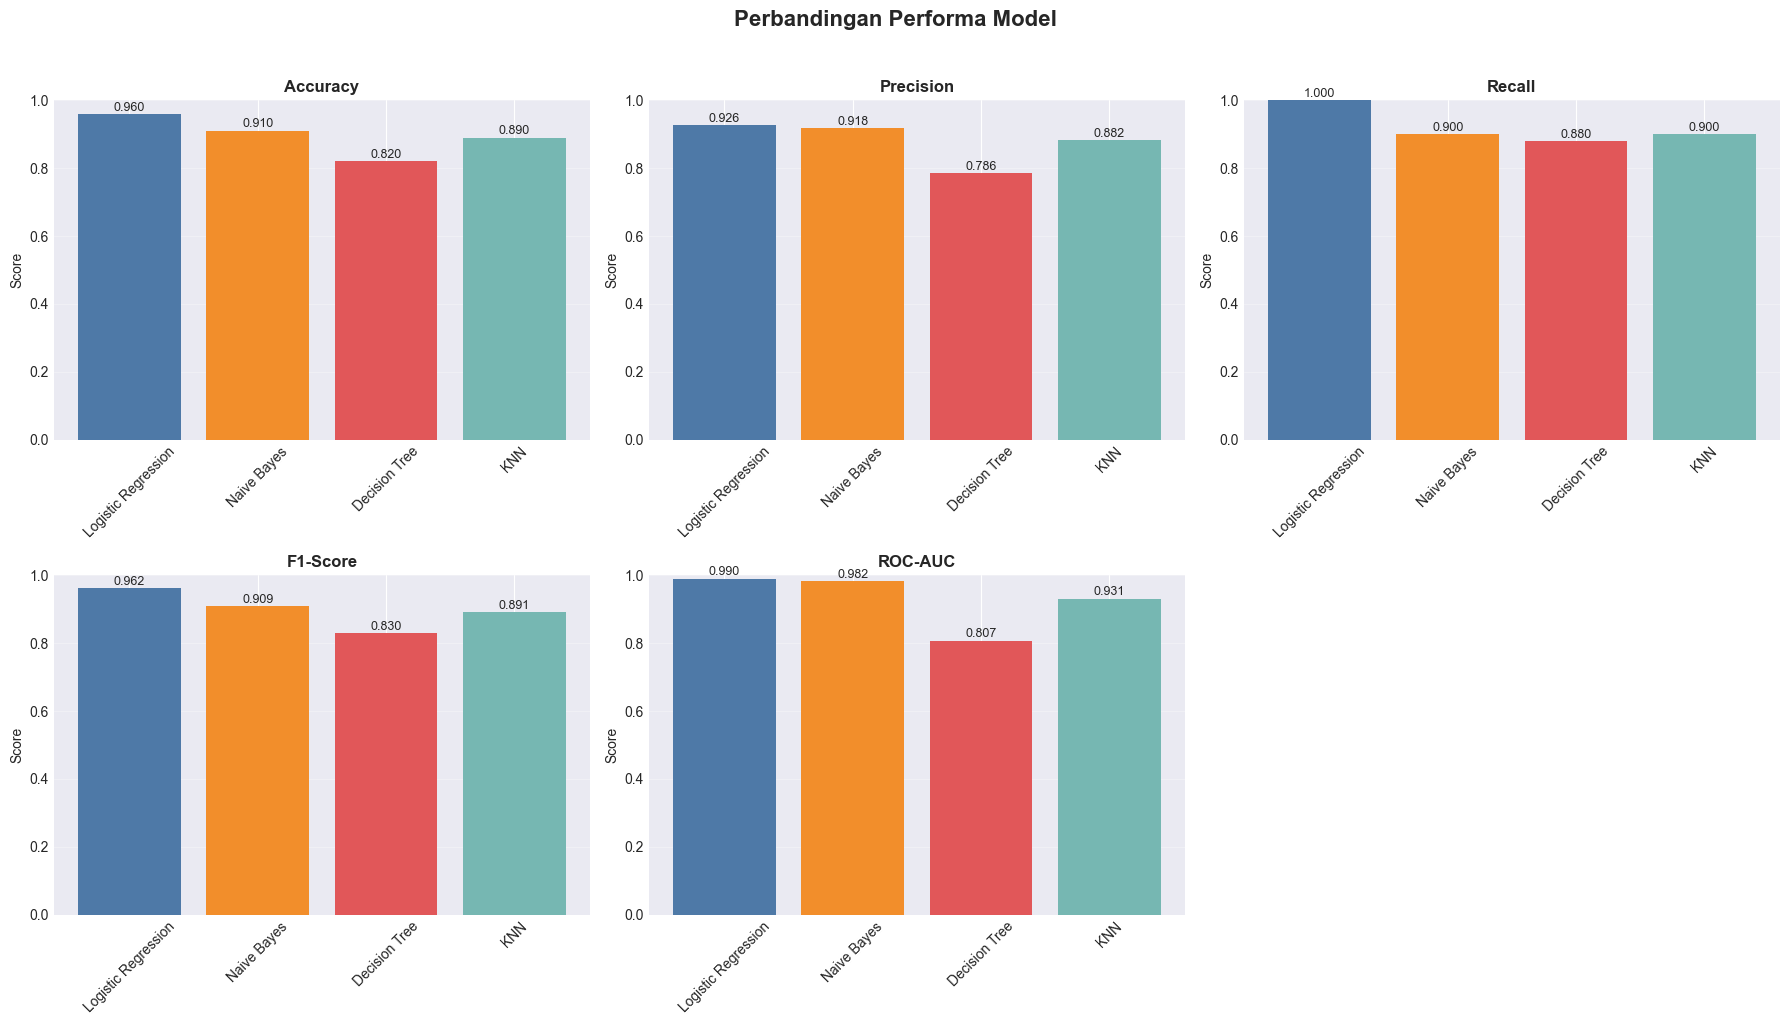

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors_list = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for idx, metric in enumerate(metrics):
    axes[idx].bar(results_df['Model'], results_df[metric], color=colors_list)
    axes[idx].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_ylim([0, 1])
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(results_df[metric]):
        axes[idx].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[5].axis('off')

plt.suptitle('Perbandingan Performa Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.3 Confusion Matrix

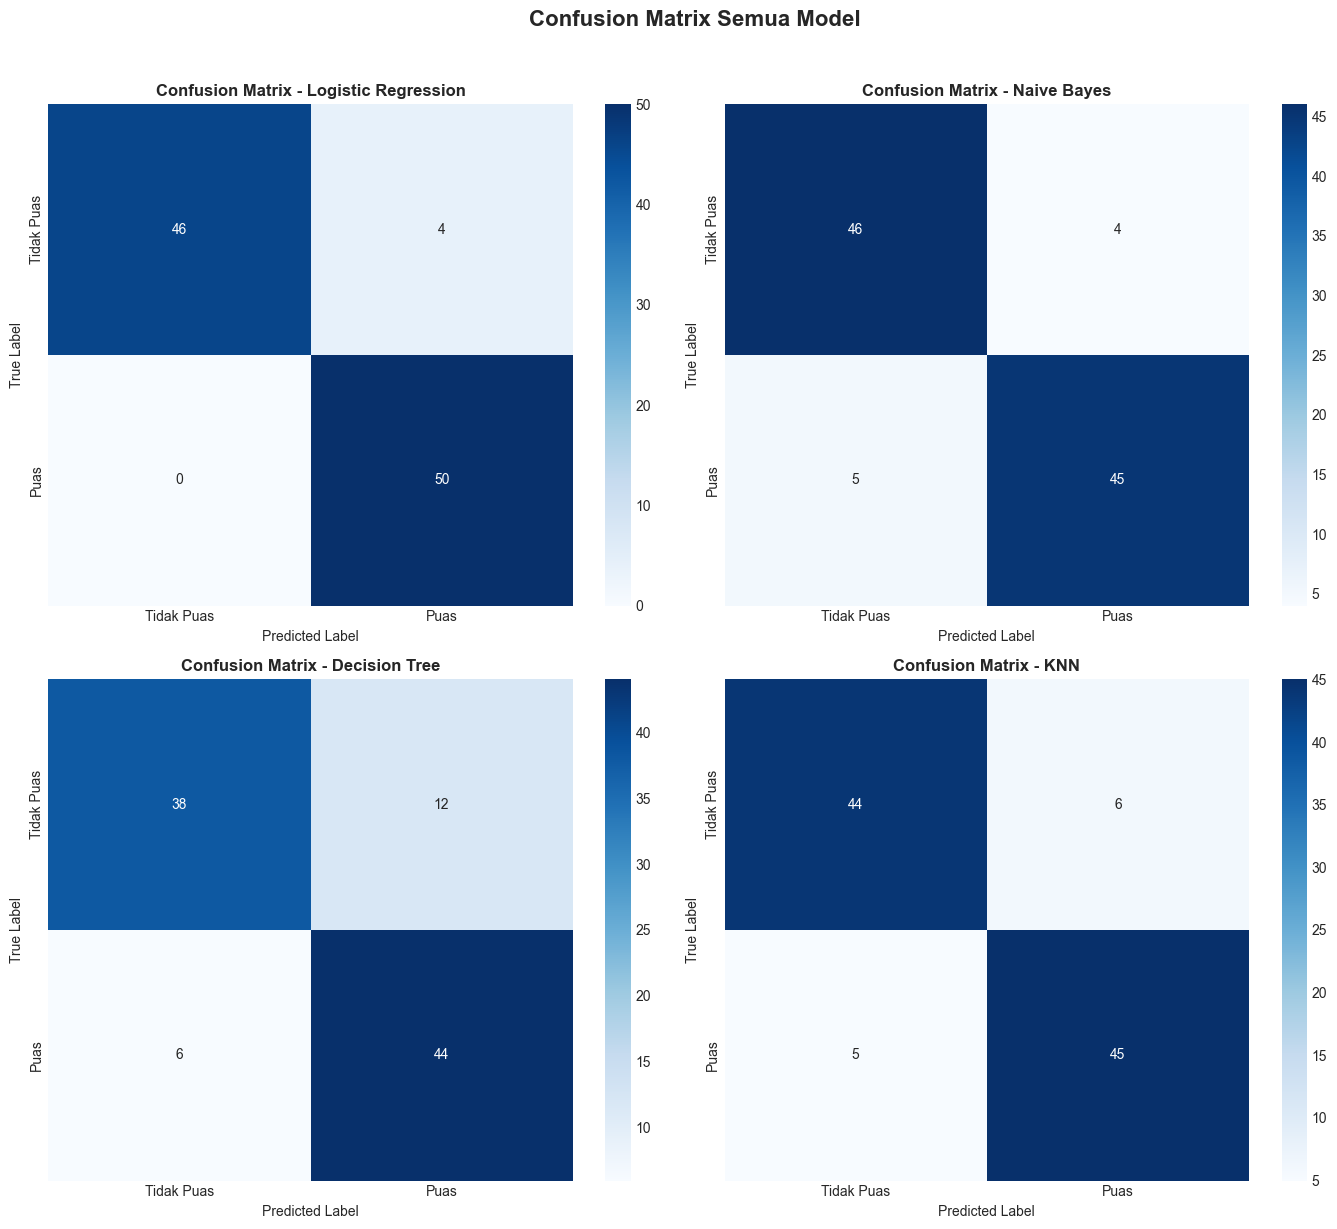

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

model_names = list(models.keys())
for idx, model_name in enumerate(model_names):
    cm = confusion_matrix(y_test, predictions[model_name])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Tidak Puas', 'Puas'],
                yticklabels=['Tidak Puas', 'Puas'])
    axes[idx].set_title(f'Confusion Matrix - {model_name}', fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrix Semua Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.4 ROC Curve

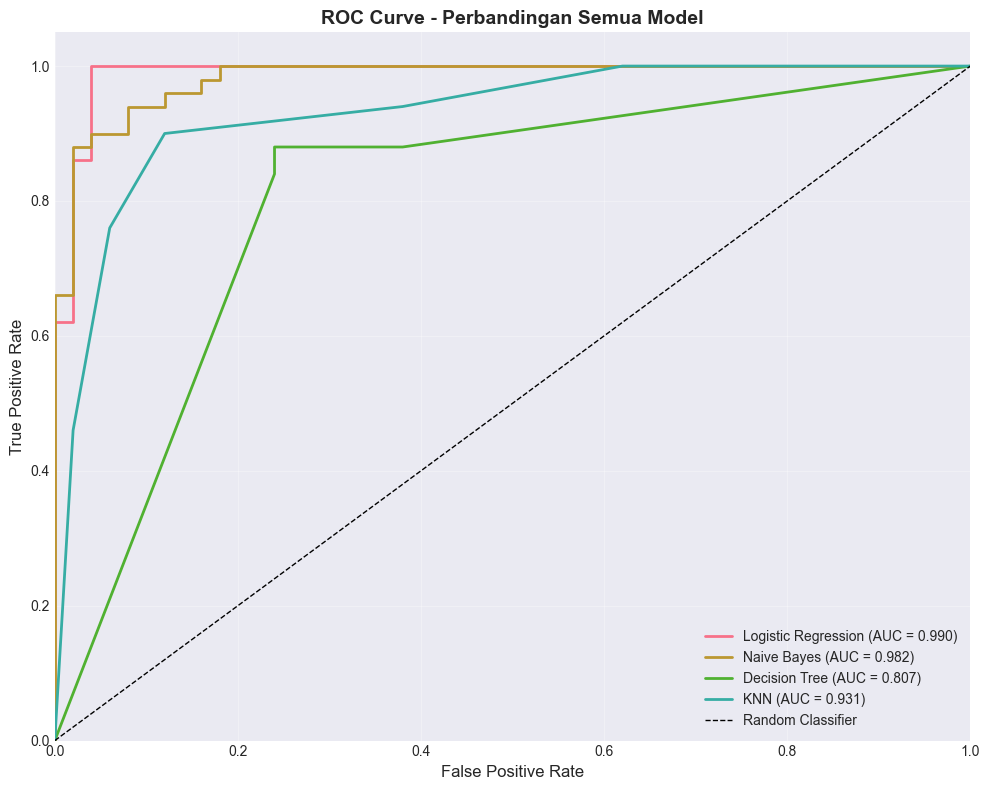

In [27]:
plt.figure(figsize=(10, 8))

for model_name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[model_name])
    roc_auc = roc_auc_score(y_test, probabilities[model_name])
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Perbandingan Semua Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.5 Classification Report

In [28]:
print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

for model_name in models.keys():
    print(f"\n{model_name}:")
    print("-" * 60)
    print(classification_report(y_test, predictions[model_name], 
                                target_names=['Tidak Puas', 'Puas']))

CLASSIFICATION REPORT

Logistic Regression:
------------------------------------------------------------
              precision    recall  f1-score   support

  Tidak Puas       1.00      0.92      0.96        50
        Puas       0.93      1.00      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100


Naive Bayes:
------------------------------------------------------------
              precision    recall  f1-score   support

  Tidak Puas       0.90      0.92      0.91        50
        Puas       0.92      0.90      0.91        50

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100


Decision Tree:
------------------------------------------------------------
              precision    recall  f1-score   support

  Tidak Puas       0.86      0.76 

## 4.6 Analisis Model Terbaik

In [29]:
print("=" * 70)
print("📊 PERBANDINGAN PERFORMA ANTAR MODEL")
print("=" * 70)

best_accuracy = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_precision = results_df.loc[results_df['Precision'].idxmax(), 'Model']
best_recall = results_df.loc[results_df['Recall'].idxmax(), 'Model']
best_f1 = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_roc_auc = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']

print(f"\n📊 Model Terbaik per Metrik:")
print(f"   Accuracy: {best_accuracy} ({results_df.loc[results_df['Accuracy'].idxmax(), 'Accuracy']:.4f})")
print(f"   Precision: {best_precision} ({results_df.loc[results_df['Precision'].idxmax(), 'Precision']:.4f})")
print(f"   Recall: {best_recall} ({results_df.loc[results_df['Recall'].idxmax(), 'Recall']:.4f})")
print(f"   F1-Score: {best_f1} ({results_df.loc[results_df['F1-Score'].idxmax(), 'F1-Score']:.4f})")
print(f"   ROC-AUC: {best_roc_auc} ({results_df.loc[results_df['ROC-AUC'].idxmax(), 'ROC-AUC']:.4f})")

results_df['Average_Score'] = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].mean(axis=1)
best_overall = results_df.loc[results_df['Average_Score'].idxmax(), 'Model']

print(f"\n🏆 Model Terbaik Keseluruhan: {best_overall}")
print(f"   Average Score: {results_df.loc[results_df['Average_Score'].idxmax(), 'Average_Score']:.4f}")

📊 PERBANDINGAN PERFORMA ANTAR MODEL

📊 Model Terbaik per Metrik:
   Accuracy: Logistic Regression (0.9600)
   Precision: Logistic Regression (0.9259)
   Recall: Logistic Regression (1.0000)
   F1-Score: Logistic Regression (0.9615)
   ROC-AUC: Logistic Regression (0.9896)

🏆 Model Terbaik Keseluruhan: Logistic Regression
   Average Score: 0.9674


## 4.7 Ensemble Voting

In [30]:
print("\n" + "=" * 70)
print("🗳️ ENSEMBLE (VOTING MAYORITAS)")
print("=" * 70)

ensemble_predictions = []
for i in range(len(y_test)):
    votes = [predictions[model][i] for model in models.keys()]
    ensemble_pred = 1 if sum(votes) > len(votes)/2 else 0
    ensemble_predictions.append(ensemble_pred)

ensemble_predictions = np.array(ensemble_predictions)

ensemble_accuracy = accuracy_score(y_test, ensemble_predictions)
ensemble_precision = precision_score(y_test, ensemble_predictions)
ensemble_recall = recall_score(y_test, ensemble_predictions)
ensemble_f1 = f1_score(y_test, ensemble_predictions)

print(f"\n📊 Hasil Ensemble Voting:")
print(f"   Accuracy: {ensemble_accuracy:.4f}")
print(f"   Precision: {ensemble_precision:.4f}")
print(f"   Recall: {ensemble_recall:.4f}")
print(f"   F1-Score: {ensemble_f1:.4f}")

best_model_acc = results_df[results_df['Model'] == best_overall]['Accuracy'].values[0]
improvement = ensemble_accuracy - best_model_acc

print(f"\n📈 Dibanding Model Terbaik ({best_overall}):")
print(f"   Model Terbaik: {best_model_acc:.4f}")
print(f"   Ensemble: {ensemble_accuracy:.4f}")

if improvement > 0:
    print(f"   ✅ Ensemble lebih baik: +{improvement:.4f}")
else:
    print(f"   ⚠️ Ensemble: {improvement:.4f}")


🗳️ ENSEMBLE (VOTING MAYORITAS)

📊 Hasil Ensemble Voting:
   Accuracy: 0.9300
   Precision: 0.9388
   Recall: 0.9200
   F1-Score: 0.9293

📈 Dibanding Model Terbaik (Logistic Regression):
   Model Terbaik: 0.9600
   Ensemble: 0.9300
   ⚠️ Ensemble: -0.0300


## 4.8 Kesimpulan

In [31]:
print("\n" + "=" * 70)
print("✅ RINGKASAN HASIL")
print("=" * 70)

print("\n📋 Data Understanding:")
print(f"   ✅ Dataset: {df.shape[0]} samples, {df.shape[1]} features")
print(f"   ✅ Tidak ada missing values setelah preprocessing")
print(f"   ✅ Target balance: {balance_ratio:.3f}")

print("\n📋 Data Preparation:")
print(f"   ✅ Atribut tidak relevan dihapus")
print(f"   ✅ Data duplikat dihapus")
print(f"   ✅ Data dikodekan dan discale")
print(f"   ✅ Train/Test split: 80/20")

print("\n📋 Modeling:")
print(f"   ✅ 4 model berhasil dilatih")
print(f"   ✅ Semua model disimpan")

print("\n📋 Evaluation:")
print(f"   ✅ Model Terbaik: {best_overall}")
print(f"   ✅ Ensemble Voting: {ensemble_accuracy:.4f}")
print(f"   ✅ Semua metrik dihitung (Accuracy, Precision, Recall, F1, ROC-AUC)")

print("\n" + "=" * 70)
print("✅ PROYEK SELESAI DAN SIAP DEPLOYMENT")
print("=" * 70)


✅ RINGKASAN HASIL

📋 Data Understanding:
   ✅ Dataset: 500 samples, 10 features
   ✅ Tidak ada missing values setelah preprocessing
   ✅ Target balance: 0.984

📋 Data Preparation:
   ✅ Atribut tidak relevan dihapus
   ✅ Data duplikat dihapus
   ✅ Data dikodekan dan discale
   ✅ Train/Test split: 80/20

📋 Modeling:
   ✅ 4 model berhasil dilatih
   ✅ Semua model disimpan

📋 Evaluation:
   ✅ Model Terbaik: Logistic Regression
   ✅ Ensemble Voting: 0.9300
   ✅ Semua metrik dihitung (Accuracy, Precision, Recall, F1, ROC-AUC)

✅ PROYEK SELESAI DAN SIAP DEPLOYMENT
